# 02 Rules: distributions, thresholds, precision and recall

**Training window only (Sep 1-6).** Thresholds are chosen here, so the test set is never opened.

Each rule is one reason code. A rule's job is to *explain* why an account looks suspicious;
ranking accounts well is mainly the models' job in Phase 5.

In [1]:
import os, sys
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.load import load_config, window_bounds
from src.features import window_days
from src.rules import RULES, score_accounts, rule_report, score_report

pd.set_option("display.width", 200)
cfg = load_config()
DAYS = window_days(*window_bounds(cfg, "train"))
f = pd.read_parquet("data/processed/features_train.parquet").merge(
    pd.read_parquet("data/processed/labels_train.parquet")[["account_id", "is_mule", "is_grey"]], on="account_id")

# Whole-window counts are easier to read than per-day rates when choosing thresholds
f["n_txn"] = (f.in_count_per_day + f.out_count_per_day) * DAYS
f["fan_in"] = (f.fan_in_per_day * DAYS).round().astype(int)
f["fan_out"] = (f.fan_out_per_day * DAYS).round().astype(int)
f["cash_btc_share"] = f.fmt_cash_share + f.fmt_bitcoin_share

active = f[f.n_txn > 0]
two_way = f[(f.in_count_per_day > 0) & (f.out_count_per_day > 0)]
mules = f[f.is_mule == 1]
base_rate = f.is_mule.mean()
print(f"accounts {len(f):,} | active {len(active):,} | two-way {len(two_way):,} | mules {len(mules)} | base rate {100*base_rate:.3f}%")

accounts 512,907 | active 408,244 | two-way 151,479 | mules 340 | base rate 0.066%


## 1. Distributions: everyone vs mules
Thresholds start from percentiles of the whole population (so a rule flags *rare* behaviour), then we check how mules sit against them.
- Dwell and pass-through ratio are compared within **two-way** accounts (they receive and send); for everyone else these features are undefined.
- **p99 = 6** means 99% of accounts are below 6.

In [2]:
qs = [0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
rows = []
for col, pop_name, pop in [("dwell_median_hours", "two-way", two_way[two_way.has_dwell == 1]),
                           ("pass_through_ratio", "two-way", two_way),
                           ("fan_in", "active", active), ("fan_out", "active", active),
                           ("first_seen_frac", "active", active), ("burst_share", "active", active),
                           ("n_txn", "active", active), ("cash_btc_share", "active", active),
                           ("cross_bank_out_share", "has outgoing", f[f.out_count_per_day > 0])]:
    rows.append([col, f"all {pop_name}"] + list(pop[col].quantile(qs).round(3)))
    rows.append([col, "mules"] + list(mules[col].quantile(qs).round(3)))
pd.DataFrame(rows, columns=["feature", "group"] + [f"p{q*100:g}" for q in qs])

,feature,group,p50,p75,p90,p95,p99,p99.9
0,dwell_median_hours,all two-way,10.900,20.075,42.694,69.193,101.852,131.411
1,dwell_median_hours,mules,17.579,48.108,76.597,95.594,168.000,168.000
2,pass_through_ratio,all two-way,1.170,10.000,10.000,10.000,10.000,10.000
3,pass_through_ratio,mules,0.991,2.040,10.000,10.000,10.000,10.000
4,fan_in,all active,1.000,2.000,3.000,3.000,6.000,24.000
5,fan_in,mules,3.000,3.000,5.000,6.000,14.000,17.000
6,fan_out,all active,1.000,1.000,3.000,5.000,8.000,14.000
7,fan_out,mules,2.000,3.000,6.000,8.000,13.220,18.966
8,first_seen_frac,all active,0.078,0.208,0.298,0.330,0.831,0.974
9,first_seen_frac,mules,0.057,0.168,0.376,0.561,0.753,0.904


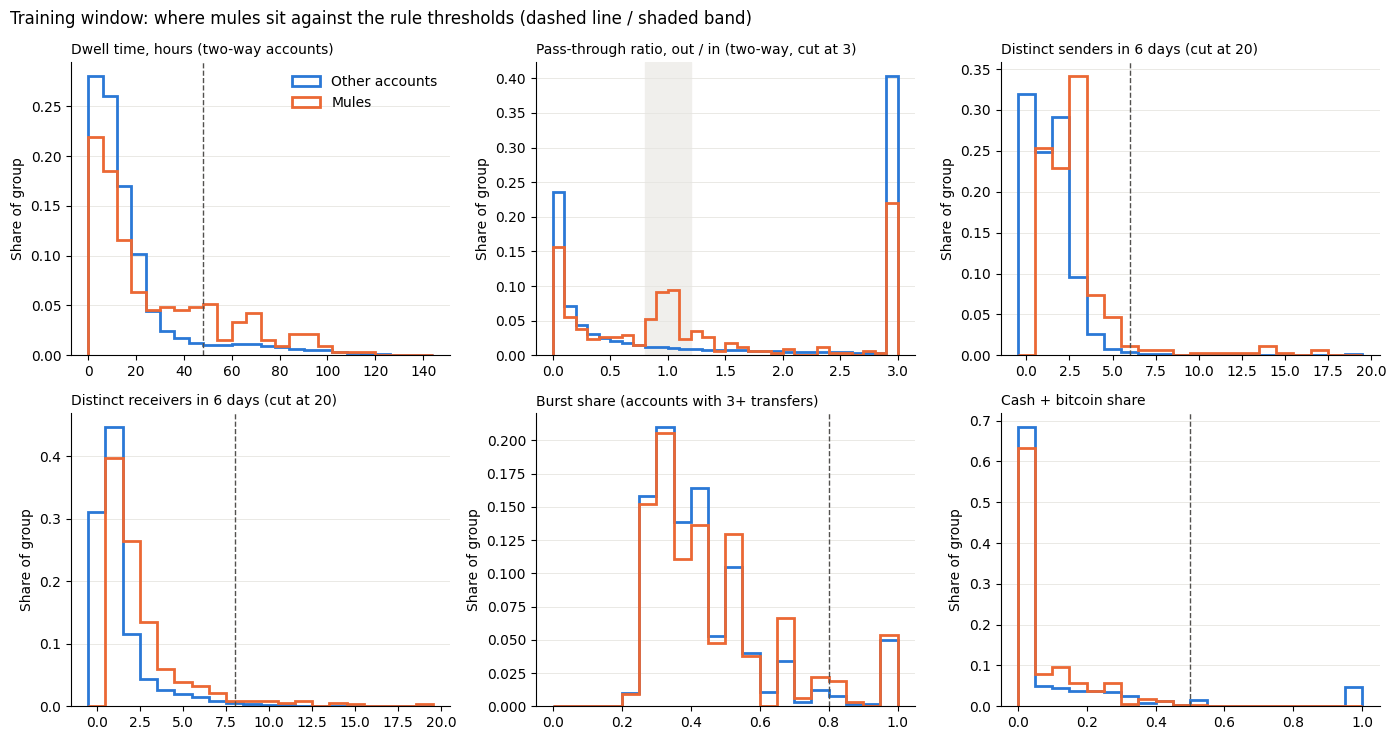

In [3]:
# Each panel compares the share of mules vs the share of other accounts in each bin.
# Shares, not counts: there are ~1,000x more non-mules, so raw counts would hide the mules entirely.
r = cfg["rules"]
panels = [
    ("dwell_median_hours", two_way[two_way.has_dwell == 1], np.linspace(0, 144, 25), r["R1_RAPID_PASS_THROUGH"]["max_dwell_hours"], "Dwell time, hours (two-way accounts)"),
    ("pass_through_ratio", two_way, np.linspace(0, 3, 31), None, "Pass-through ratio, out / in (two-way, cut at 3)"),
    ("fan_in", active, np.arange(0, 21) - 0.5, 6, "Distinct senders in 6 days (cut at 20)"),
    ("fan_out", active, np.arange(0, 21) - 0.5, 8, "Distinct receivers in 6 days (cut at 20)"),
    ("burst_share", active[active.n_txn >= 3], np.linspace(0, 1, 21), r["R4_NEW_AND_BURSTY"]["min_burst_share"], "Burst share (accounts with 3+ transfers)"),
    ("cash_btc_share", active, np.linspace(0, 1, 21), r["R5_HIGH_RISK_CHANNEL"]["min_cash_bitcoin_share"], "Cash + bitcoin share"),
]
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for ax, (col, pop, bins, threshold, title) in zip(axes.flat, panels):
    others, mule_vals = pop.loc[pop.is_mule == 0, col].clip(upper=bins[-1]), pop.loc[pop.is_mule == 1, col].clip(upper=bins[-1])
    for vals, colour, label in [(others, "#2a78d6", "Other accounts"), (mule_vals, "#eb6834", "Mules")]:
        ax.hist(vals, bins=bins, weights=np.full(len(vals), 1 / len(vals)), histtype="step", linewidth=2, color=colour, label=label)
    if threshold is not None:
        ax.axvline(threshold, color="#52514e", linestyle="--", linewidth=1)
    if col == "pass_through_ratio":
        ax.axvspan(r["R1_RAPID_PASS_THROUGH"]["min_pass_through_ratio"], r["R1_RAPID_PASS_THROUGH"]["max_pass_through_ratio"], color="#f0efec", zorder=0)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_ylabel("Share of group")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e6e5e1", linewidth=0.6)
axes.flat[0].legend(frameon=False)
fig.suptitle("Training window: where mules sit against the rule thresholds (dashed line / shaded band)", x=0.01, ha="left")
fig.tight_layout()
Path("reports/figures").mkdir(parents=True, exist_ok=True)
fig.savefig("reports/figures/02_rule_distributions.png", dpi=150)
plt.show()

**Reading the plots**
- **Pass-through ratio** is the clearest signal: mules pile up near 1.0 (inside the shaded band), while other two-way accounts are spread out.
- **Dwell time** does *not* separate mules from other two-way accounts. Other forwarders are, if anything, faster (median about 12h vs about 18h). Dwell only helps in combination with the ratio.
- **Fan-in / fan-out**: mules have somewhat more counterparties, but the overlap is large.
- **Burst**: mules are *less* bursty, the opposite of the rule's idea.
- **Cash + bitcoin**: mules almost never use them in this simulator.

## 2. Threshold candidates (training precision and recall)
**Lift** = precision / base rate: how many times better than picking accounts at random.

In [4]:
def evaluate(mask, name):
    hit = f[mask]
    precision = hit.is_mule.mean() if len(hit) else 0
    return dict(candidate=name, flagged=len(hit), mules=int(hit.is_mule.sum()),
                precision_pct=round(100 * precision, 2), recall_pct=round(100 * hit.is_mule.sum() / len(mules), 1),
                lift=round(precision / base_rate, 1))

cands = []
for x in [6, 12, 24, 48]:
    for a, b in [(0.5, 1.5), (0.8, 1.2), (0.9, 1.1)]:
        cands.append(evaluate((f.has_dwell == 1) & (f.dwell_median_hours < x) & f.pass_through_ratio.between(a, b),
                              f"R1 dwell<{x}h & ratio [{a},{b}]"))
for k in [3, 5, 6, 8, 10, 15]:
    cands.append(evaluate(f.fan_in >= k, f"R2 fan_in>={k}"))
for k in [3, 5, 8, 10, 15]:
    cands.append(evaluate(f.fan_out >= k, f"R3 fan_out>={k}"))
for fs, bs, mn in [(0.5, 0.8, 1), (0.5, 0.8, 3), (0.7, 0.8, 3), (0.5, 0.9, 5)]:
    cands.append(evaluate((f.first_seen_frac >= fs) & (f.burst_share >= bs) & (f.n_txn >= mn),
                          f"R4 first_seen>={fs} & burst>={bs} & txns>={mn}"))
for h in [0.3, 0.5, 0.8]:
    cands.append(evaluate(f.cash_btc_share >= h, f"R5 cash+btc>={h}"))
for k in [1, 3, 5]:
    cands.append(evaluate((f.cross_bank_out_share >= 1.0) & (f.out_count_per_day * DAYS >= k), f"R6 all cross-bank & outgoing>={k}"))
pd.DataFrame(cands)

,candidate,flagged,mules,precision_pct,recall_pct,lift
0,"R1 dwell<6h & ratio [0.5,1.5]",4396,28,0.64,8.2,9.6
1,"R1 dwell<6h & ratio [0.8,1.2]",1618,19,1.17,5.6,17.7
2,"R1 dwell<6h & ratio [0.9,1.1]",789,13,1.65,3.8,24.9
3,"R1 dwell<12h & ratio [0.5,1.5]",9051,44,0.49,12.9,7.3
4,"R1 dwell<12h & ratio [0.8,1.2]",3332,31,0.93,9.1,14.0
5,"R1 dwell<12h & ratio [0.9,1.1]",1627,22,1.35,6.5,20.4
6,"R1 dwell<24h & ratio [0.5,1.5]",13827,68,0.49,20.0,7.4
7,"R1 dwell<24h & ratio [0.8,1.2]",5053,47,0.93,13.8,14.0
8,"R1 dwell<24h & ratio [0.9,1.1]",2483,32,1.29,9.4,19.4
9,"R1 dwell<48h & ratio [0.5,1.5]",15596,95,0.61,27.9,9.2


## 3. Chosen rules (from config.yaml)
| Rule | Threshold | Why |
|---|---|---|
| R1 RAPID_PASS_THROUGH | dwell < 48h AND ratio in [0.8, 1.2] | Beat 24h on both precision and recall |
| R2 FAN_IN | 6+ senders in 6 days (1.0/day) | About p99 of active accounts |
| R3 FAN_OUT | 8+ receivers in 6 days (1.333/day) | About p99 of active accounts |
| R4 NEW_AND_BURSTY | first seen 50%+ into window AND burst 0.8+ AND 3+ transfers | Minimum activity stops 1-2 transfer accounts trivially counting as bursty |
| R5 HIGH_RISK_CHANNEL | cash + bitcoin 50%+ | Kept as a reason code, weight 0 (worse than random here) |
| R6 CROSS_BANK_HOPS | all outgoing cross-bank AND 3+ outgoing | Kept as a reason code, weight 0 (nearly all transfers are cross-bank here) |

Score weights = rounded training lift: R1 16, R2 6, R3 4, R4 17, R5 0, R6 0.

In [5]:
scored = score_accounts(f.drop(columns=["n_txn", "fan_in", "fan_out", "cash_btc_share", "is_mule", "is_grey"]), cfg["rules"], DAYS)
labels = f[["account_id", "is_mule", "is_grey"]]
rule_report(scored, labels).round(2)

,accounts_flagged,mules_caught,grey_among_flagged,precision_pct,recall_pct,lift
R1_RAPID_PASS_THROUGH,5683.0,62.0,58.0,1.09,18.24,16.46
R2_FAN_IN,4536.0,19.0,282.0,0.42,5.59,6.32
R3_FAN_OUT,6106.0,18.0,91.0,0.29,5.29,4.45
R4_NEW_AND_BURSTY,866.0,10.0,63.0,1.15,2.94,17.42
R5_HIGH_RISK_CHANNEL,26118.0,1.0,66.0,0.00,0.29,0.06
R6_CROSS_BANK_HOPS,119524.0,166.0,1098.0,0.14,48.82,2.10


In [6]:
score_report(scored, labels).round(2)

,accounts_flagged,mules_caught,precision_pct,recall_pct
score >= 4,16409.0,98.0,0.60,28.82
score >= 6,10524.0,83.0,0.79,24.41
score >= 10,6587.0,67.0,1.02,19.71
score >= 16,6539.0,64.0,0.98,18.82
score >= 17,1107.0,10.0,0.90,2.94
score >= 20,732.0,8.0,1.09,2.35
score >= 22,561.0,8.0,1.43,2.35
score >= 23,493.0,8.0,1.62,2.35
score >= 26,12.0,8.0,66.67,2.35
score >= 33,10.0,8.0,80.00,2.35


## 4. Which combinations fire together?
Precision jumps at score 33 = **R1 + R4**: an account that appears late in the window, does almost all its activity in one 24-hour stretch, and passes the money straight through. Only about 10 training accounts show it, but most are mules. The "gather-scatter" combination R1 + R2 + R3 (score 26) is rarer still and caught no mules in training.

In [7]:
combo = scored[scored.n_rules_fired > 0].merge(labels, on="account_id")
combo["rules"] = combo[RULES].apply(lambda r: " + ".join(c.split("_")[0] for c in RULES if r[c]), axis=1)
(combo.groupby("rules").agg(accounts=("is_mule", "size"), mules=("is_mule", "sum"), grey=("is_grey", "sum"))
      .assign(precision_pct=lambda d: (100 * d.mules / d.accounts).round(1))
      .sort_values("accounts", ascending=False).head(15))

,accounts,mules,grey,precision_pct
rules,,,,
R6,105413,127,947,0.1
R5,21629,0,44,0.0
R3 + R6,4321,9,44,0.2
R1 + R6,4259,18,31,0.4
R5 + R6,4151,1,17,0.0
R2,2869,8,175,0.3
R3,1493,6,31,0.4
R1,1031,36,21,3.5
R2 + R6,967,8,40,0.8


## 5. What analysts would see: example reason codes (training window)

In [8]:
view = scored.merge(labels, on="account_id").sort_values("rule_score", ascending=False)
pd.set_option("display.max_colwidth", 200)
print("Top-scored MULES:")
print(view[view.is_mule == 1].head(3)[["account_id", "rule_score", "reason_codes"]].to_string(index=False))
print("\nTop-scored NON-mules (are they grey, i.e. touched laundering money?):")
print(view[view.is_mule == 0].head(5)[["account_id", "rule_score", "is_grey", "reason_codes"]].to_string(index=False))

Top-scored MULES:
       account_id  rule_score                                                                                                                                                  reason_codes
0028531_80A709C90          33   RAPID_PASS_THROUGH: forwarded 92% of incoming money, median wait 0.7h | NEW_AND_BURSTY: first seen 55% into the window, 100% of activity in one 24h stretch
0043818_8105FFAD0          33 RAPID_PASS_THROUGH: forwarded 106% of incoming money, median wait 22.8h | NEW_AND_BURSTY: first seen 54% into the window, 100% of activity in one 24h stretch
 014549_8045C0B70          33  RAPID_PASS_THROUGH: forwarded 108% of incoming money, median wait 4.3h | NEW_AND_BURSTY: first seen 71% into the window, 100% of activity in one 24h stretch

Top-scored NON-mules (are they grey, i.e. touched laundering money?):
       account_id  rule_score  is_grey                                                                                                                         

## 6. Findings
- The best single rules (R1, R4) are about **16-17x better than random**, yet over 98% of what they flag is not a label-B mule.
- **R1 + R4 together** (new, bursty, fast pass-through) is the strongest signal: about 10 accounts in training, most of them mules. It covers only a few percent of mules, so most mules show no strong rule combination.
- **R5 and R6 don't work on this data**: cash and bitcoin are used mostly by normal accounts, and nearly every transfer is cross-bank. They stay as reason codes (real bank data may differ) with weight 0.
- Many flagged non-mules are **grey** (they touched laundering money without being pass-through), so the rules are less wrong than their precision suggests.
- Conclusion: rules are good for **explaining** a flag and as a transparent **baseline**. Ranking needs the combined evidence of a model (Phase 5) and graph context (Phase 4).